### Генерация поэзии с помощью нейронных сетей: шаг 1
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерироват стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [1]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [2]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

cuda device is available


#### 1. Загрузка данных.

In [3]:
# do not change the code in the block below
# __________start of block__________
!wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt

with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()

text = "".join([x.replace('\t\t', '').lower() for x in text])
# __________end of block__________

--2024-11-14 02:59:29--  https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt’

onegin.txt          100%[===================>] 256.37K  --.-KB/s    in 0.02s   

2024-11-14 02:59:30 (11.8 MB/s) - ‘onegin.txt’ saved [262521/262521]



#### 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [4]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text.lower())) + ['<sos>']
num_tokens = len(tokens)

assert num_tokens == 84, "Check the tokenization process"

token_to_idx = {x: idx for idx, x in enumerate(tokens)}
idx_to_token = {idx: x for idx, x in enumerate(tokens)}

assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")


text_encoded = [token_to_idx[x] for x in text]
# __________end of block__________

Seems fine!


__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [5]:
# do not change the code in the block below
# __________start of block__________
batch_size = 256
seq_length = 100
start_column = np.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>']

def generate_chunk():
    global text_encoded, start_column, batch_size, seq_length

    start_index = np.random.randint(0, len(text_encoded) - batch_size*seq_length - 1)
    data = np.array(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    yield np.hstack((start_column, data))
# __________end of block__________

Пример батча:

In [ ]:
next(generate_chunk())

array([[84, 54,  1, ...,  0, 69, 53],
       [84, 60, 53, ..., 55, 59, 50],
       [84,  1, 57, ..., 53, 55, 53],
       ...,
       [84,  1, 74, ..., 49, 53, 63],
       [84,  1, 58, ..., 56, 45, 62],
       [84, 73,  1, ..., 45, 61, 62]])

Далее вам предстоит написать код для обучения модели и генерации текста.

In [44]:
class RNN(nn.Module):
  def __init__(self, input_size, output_size, hidden_size):
    super(RNN, self).__init__()
    self.input_size = input_size
    self.output_size = output_size
    self.hidden_size = hidden_size

    self.encoder = nn.Embedding(self.input_size, self.hidden_size)
    self.rnn = nn.GRU(self.hidden_size, self.hidden_size, batch_first=True)
    self.decoder = nn.Linear(self.hidden_size, self.output_size)

  def forward(self, input, hidden):
    encoded = self.encoder(input)
    output, hidden = self.rnn(encoded, hidden)
    output = self.decoder(output)
    return output, hidden

  def init_hidden(self, batch_size):
    return torch.zeros(1, batch_size, self.hidden_size)

In [46]:
def random_training_set():
    chunk = next(generate_chunk())
    inp = torch.tensor(chunk[:, :-1], dtype=torch.long)
    target = torch.tensor(chunk[:, 1:], dtype=torch.long)
    return inp, target

def train(model, inp, target, batch_size):
    batch_size = inp.size(0)
    hidden = model.init_hidden(batch_size).to(inp.device)
    model.zero_grad()

    output, hidden = model(inp, hidden)

    output = output.view(-1, model.output_size)
    target = target.view(-1)
    loss = criterion(output, target)

    loss.backward()
    decoder_optimizer.step()

    return loss.item()



In [50]:
from tqdm.auto import tqdm
n_epochs = 2000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 1
lr = 0.005

decoder = RNN(num_tokens, num_tokens, hidden_size)
decoder_optimizer = torch.optim.Adam(decoder.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

all_losses = []
loss_avg = 0

for epoch in tqdm(range(1, n_epochs + 1)):
    inp, target = random_training_set()
    loss = train(decoder, inp, target, batch_size)
    loss_avg += loss

    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0.0

    if epoch % print_every == 0:
        print(f"Epoch {epoch}/{n_epochs}, Loss: {loss:.4f}")

  0%|          | 0/2000 [00:00<?, ?it/s]

Epoch 100/2000, Loss: 2.2267
Epoch 200/2000, Loss: 2.0000
Epoch 300/2000, Loss: 1.8464
Epoch 400/2000, Loss: 1.8685
Epoch 500/2000, Loss: 1.7329
Epoch 600/2000, Loss: 1.7159
Epoch 700/2000, Loss: 1.6555
Epoch 800/2000, Loss: 1.8123
Epoch 900/2000, Loss: 1.7611
Epoch 1000/2000, Loss: 1.6379
Epoch 1100/2000, Loss: 1.5942
Epoch 1200/2000, Loss: 1.5767
Epoch 1300/2000, Loss: 1.7061
Epoch 1400/2000, Loss: 1.5650
Epoch 1500/2000, Loss: 1.5665
Epoch 1600/2000, Loss: 1.5326
Epoch 1700/2000, Loss: 1.5241
Epoch 1800/2000, Loss: 1.5920
Epoch 1900/2000, Loss: 1.5358
Epoch 2000/2000, Loss: 1.7834


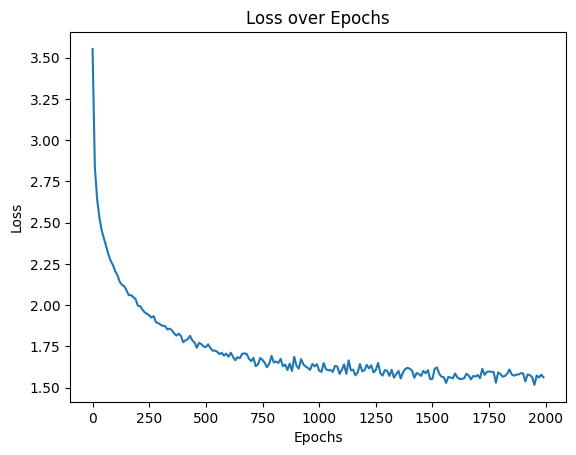

In [52]:
plt.plot(range(0, n_epochs, plot_every), all_losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.show()

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [67]:
import torch
import torch.nn.functional as F

def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device='cpu'):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    :param device: device to run the model on (e.g., 'cpu' or 'cuda')
    '''

    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else:
        x_sequence = [token_to_idx['<sos>']]

    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)

    hidden = char_rnn.init_hidden(x_sequence.size(0))

    generated_sequence = list(x_sequence.cpu().data.numpy()[0])
    char_rnn.eval()

    for _ in range(max_length - len(generated_sequence)):
        output, hidden = char_rnn(x_sequence, hidden)

        output = output[:, -1, :]
        output = output / temperature
        probabilities = F.softmax(output, dim=-1).cpu().data.numpy()

        next_token_idx = np.random.choice(len(probabilities[0]), p=probabilities[0])

        generated_sequence.append(next_token_idx)

        x_sequence = torch.tensor([[next_token_idx]], dtype=torch.int64).to(device)

    generated_text = ''.join([tokens[ix] for ix in generated_sequence])
    return generated_text


Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [72]:
print(generate_sample(decoder, 'мой дядя самых честных правил', max_length=500, temperature=0.8)[5:])

мой дядя самых честных правили шумной волненьем,
онегин прахомим своетом.



xxvii

с сенею сердце моей своей.
в собранье грубом,
он подруго мости, сердцем светлетно на вольно на встаранный шумны
замор от деловете,
благороть бурный находит же началковые дерде!
«подитель мысли не поздна
и давно.
забогом
какой,
татьяна своих печальной старины,
и темное глубокою
околенья с причуда,
они
зимое мечтум дрожит и спарико странный детей
ни страндый в ранчик
услышли доселы;
он вирный меня изграть он их по
